In [1]:
import os, pickle
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

OUTPUT_DIR  = '/Users/tm/Documents/GitHub/Project-for-Work/data/processed'
RANDOM_SEED = 42
BATCH_SIZE  = 512
TRAIN_NEG_RATIO = 3

# โหลดข้อมูลและสร้าง DataLoaders ใหม่
feature_matrix = pd.read_csv('/Users/tm/Documents/GitHub/Project-for-Work/data/processed/feature_matrix.csv')
with open('/Users/tm/Documents/GitHub/Project-for-Work/data/processed/feature_cols.pkl', 'rb') as _f:
    feature_cols = pickle.load(_f)
with open('/Users/tm/Documents/GitHub/Project-for-Work/data/processed/scaler.pkl', 'rb') as _f:
    scaler = pickle.load(_f)

# Entity-aware split (same logic as stage 10)
from sklearn.model_selection import train_test_split
entities = feature_matrix['entity_id_a'].dropna().unique()
train_ent, test_ent = train_test_split(entities, test_size=0.30, random_state=RANDOM_SEED)
val_ent,  test_ent  = train_test_split(test_ent,  test_size=0.50, random_state=RANDOM_SEED)
train_df = feature_matrix[feature_matrix['entity_id_a'].isin(train_ent)]
val_df   = feature_matrix[feature_matrix['entity_id_a'].isin(val_ent)]
test_df  = feature_matrix[feature_matrix['entity_id_a'].isin(test_ent)]

# Balance training
train_pos = train_df[train_df['label'] == 1]
train_neg = train_df[train_df['label'] == 0].sample(n=min(len(train_pos)*TRAIN_NEG_RATIO, len(train_df[train_df['label']==0])), random_state=RANDOM_SEED)
train_balanced = pd.concat([train_pos, train_neg]).sample(frac=1, random_state=RANDOM_SEED)

X_train = scaler.transform(train_balanced[feature_cols].values)
y_train = train_balanced['label'].values.astype(np.float32)
X_val   = scaler.transform(val_df[feature_cols].values)
y_val   = val_df['label'].values.astype(np.float32)
X_test  = scaler.transform(test_df[feature_cols].values)
y_test  = test_df['label'].values.astype(np.float32)

class PairDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(PairDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(PairDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(PairDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

n_neg_b = (y_train == 0).sum()
n_pos_b = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg_b / max(n_pos_b, 1)], dtype=torch.float32)
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
print(f'pos_weight: {pos_weight.item():.2f}')


Train: 64,544 | Val: 24,168 | Test: 25,053
pos_weight: 3.00


---
## Stage 11: Model Training

**วัตถุประสงค์:** Train binary classifier ทำนายว่าคู่ profiles เป็นคนเดียวกันหรือไม่

**Input:** `train_loader`, `val_loader` (จาก Stage 10), `pos_weight`  
**Output:** `model.pt`, `training_history.csv`

| Sub-step | หน้าที่ |
|----------|--------|
| 11.1 | Model Architecture + Loss |
| 11.2 | Training Loop + Early Stopping |
| 11.3 | Training Curves Visualization |

### Step 11.1: Model Architecture Definition
MLP: Input → [Linear→BN→ReLU→Dropout] ×3 → Output + FocalLoss

In [2]:
# --- 11.1 Model Architecture ---
import torch
import torch.nn as nn

class FocalLoss(nn.Module):
    """Focal Loss สำหรับ class imbalance — ลด weight ของ easy examples"""
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()

class IdentityMLP(nn.Module):
    """MLP สำหรับ Identity Resolution: Input → 256 → 128 → 64 → 1"""
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.extend([nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)])
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x).squeeze(-1)

# สร้าง model
input_dim = len(feature_cols)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = IdentityMLP(input_dim=input_dim).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("📊 Step 11.1: Model Architecture")
print("=" * 60)
print(f"  Device          : {device}")
print(f"  Input dim       : {input_dim}")
print(f"  Architecture    : {input_dim} → 256 → 128 → 64 → 1")
print(f"  Total params    : {total_params:,}")
print(f"  Trainable       : {trainable:,}")
print(model)
print(f"\n✅ Step 11.1 เสร็จ")

📊 Step 11.1: Model Architecture
  Device          : cpu
  Input dim       : 17
  Architecture    : 17 → 256 → 128 → 64 → 1
  Total params    : 46,721
  Trainable       : 46,721
IdentityMLP(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

✅ Step 11.1 เสร็จ


### Step 11.2: Training Loop + Early Stopping

In [3]:
# --- 11.2 Training Loop ---
MAX_EPOCHS = 50
LR = 1e-3
PATIENCE = 5

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = FocalLoss(gamma=2.0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

# Early Stopping
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0
history = []

print("📊 Step 11.2: Training Loop")
print("=" * 60)
print(f"  Epochs: {MAX_EPOCHS}, LR: {LR}, Patience: {PATIENCE}")
print(f"  Loss: FocalLoss(gamma=2.0)")
print("-" * 60)

for epoch in range(MAX_EPOCHS):
    # --- Train ---
    model.train()
    train_losses, train_correct, train_total = [], 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        preds = (torch.sigmoid(logits) >= 0.5).float()
        train_correct += (preds == y_batch).sum().item()
        train_total += len(y_batch)
    
    # --- Validate ---
    model.eval()
    val_losses, val_correct, val_total = [], 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_losses.append(loss.item())
            preds = (torch.sigmoid(logits) >= 0.5).float()
            val_correct += (preds == y_batch).sum().item()
            val_total += len(y_batch)
    
    scheduler.step()
    
    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    train_acc = train_correct / max(train_total, 1)
    val_acc = val_correct / max(val_total, 1)
    
    history.append({'epoch': epoch+1, 'train_loss': train_loss, 'val_loss': val_loss,
                    'train_acc': train_acc, 'val_acc': val_acc})
    
    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), '/Users/tm/Documents/GitHub/Project-for-Work/data/processed/model.pt')
    else:
        patience_counter += 1
    
    marker = ' ← BEST' if patience_counter == 0 else ''
    print(f"  Epoch {epoch+1:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
          f"train_acc={train_acc:.3f} val_acc={val_acc:.3f}{marker}")
    
    if patience_counter >= PATIENCE:
        print(f"\n  ⏹️ Early stopping at epoch {epoch+1} (patience={PATIENCE})")
        break

# Load best model
model.load_state_dict(torch.load('/Users/tm/Documents/GitHub/Project-for-Work/data/processed/model.pt', weights_only=True))

history_df = pd.DataFrame(history)
history_df.to_csv('/Users/tm/Documents/GitHub/Project-for-Work/data/processed/training_history.csv', index=False)

print(f"\n  🏆 Best epoch: {best_epoch} (val_loss={best_val_loss:.4f})")
print(f"  💾 Saved: model.pt, training_history.csv")
print(f"\n✅ Step 11.2 เสร็จ")

📊 Step 11.2: Training Loop
  Epochs: 50, LR: 0.001, Patience: 5
  Loss: FocalLoss(gamma=2.0)
------------------------------------------------------------


  Epoch   1 | train_loss=0.0397 val_loss=0.0228 | train_acc=0.959 val_acc=0.978 ← BEST


  Epoch   2 | train_loss=0.0310 val_loss=0.0215 | train_acc=0.968 val_acc=0.978 ← BEST


  Epoch   3 | train_loss=0.0308 val_loss=0.0209 | train_acc=0.969 val_acc=0.978 ← BEST


  Epoch   4 | train_loss=0.0298 val_loss=0.0208 | train_acc=0.968 val_acc=0.979 ← BEST


...

  Epoch  12 | train_loss=0.0288 val_loss=0.0205 | train_acc=0.970 val_acc=0.982


  Epoch  13 | train_loss=0.0280 val_loss=0.0207 | train_acc=0.970 val_acc=0.981


  Epoch  14 | train_loss=0.0278 val_loss=0.0207 | train_acc=0.971 val_acc=0.982


  Epoch  15 | train_loss=0.0279 val_loss=0.0207 | train_acc=0.971 val_acc=0.981


  Epoch  16 | train_loss=0.0282 val_loss=0.0206 | train_acc=0.971 val_acc=0.980

  ⏹️ Early stopping at epoch 16 (patience=5)

  🏆 Best epoch: 11 (val_loss=0.0204)
  💾 Saved: model.pt, training_history.csv

✅ Step 11.2 เสร็จ


### Step 11.3: Training Curves Visualization

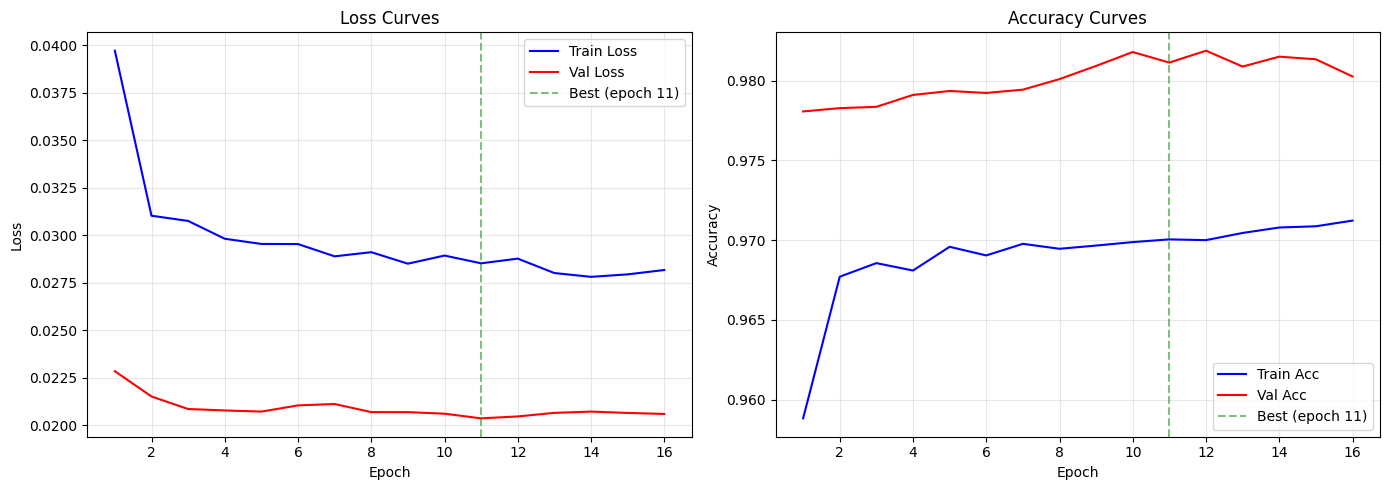


✅ Stage 11 COMPLETE — Model trained & saved


In [4]:
# --- 11.3 Training Curves ---
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_df['epoch'], history_df['train_loss'], 'b-', label='Train Loss')
ax1.plot(history_df['epoch'], history_df['val_loss'], 'r-', label='Val Loss')
ax1.axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Loss Curves')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history_df['epoch'], history_df['train_acc'], 'b-', label='Train Acc')
ax2.plot(history_df['epoch'], history_df['val_acc'], 'r-', label='Val Acc')
ax2.axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy Curves')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/tm/Documents/GitHub/Project-for-Work/data/processed/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print(f"✅ Stage 11 COMPLETE — Model trained & saved")
print(f"{'='*60}")